# 🎶 Spotify Hit Predictor


**Notebook 1 — Exploración y preparación de datos**

**Rol responsable:** Data Scientist / Analista de Datos





In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/raw/spotify-tracks-dataset.csv")

In [4]:
df.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [8]:
# Tamaño y estructura
print("Filas y columnas:", df.shape)

print("\nInformación general:")
df.info()

Filas y columnas: (114000, 22)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness   

In [7]:
# Resumen
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,114000.0,NaN,NaN,NaN,56999.5,32909.109681,0.0,28499.75,56999.5,85499.25,113999.0
Unnamed: 0,114000.0,NaN,NaN,NaN,56999.5,32909.109681,0.0,28499.75,56999.5,85499.25,113999.0
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,113999,31437,The Beatles,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,113999,46589,Alternative Christmas 2022,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,113999,73608,Run Rudolph Run,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,114000.0,NaN,NaN,NaN,33.238535,22.305078,0.0,17.0,35.0,50.0,100.0
duration_ms,114000.0,NaN,NaN,NaN,228029.153114,107297.712645,0.0,174066.0,212906.0,261506.0,5237295.0
explicit,114000,2,False,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,114000.0,NaN,NaN,NaN,0.5668,0.173542,0.0,0.456,0.58,0.695,0.985


In [9]:
df.columns.tolist()

['Unnamed: 0.1',
 'Unnamed: 0',
 'track_id',
 'artists',
 'album_name',
 'track_name',
 'popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'track_genre']

In [10]:
df[["Unnamed: 0.1", "Unnamed: 0"]].head(10)

,Unnamed: 0.1,Unnamed: 0
0,0,0
1,1,1
2,2,2
3,3,3
4,4,4
5,5,5
6,6,6
7,7,7
8,8,8
9,9,9


## Hallazgo inicial: estructura del dataset

El dataset contiene 114.000 registros y 22 variables.

Se identificaron dos columnas denominadas `Unnamed: 0.1` y `Unnamed: 0`, que aparentemente corresponden a índices generados durante exportaciones previas del archivo y no representan características musicales de las canciones.

También se observaron valores nulos mínimos en `artists`, `album_name` y `track_name` (un registro en cada variable). Estas variables se revisarán durante la etapa de calidad y limpieza.

Las variables `popularity`, `track_genre` y las características de audio como `danceability`, `energy`, `valence`, `tempo` e `instrumentalness` son relevantes para el objetivo del proyecto.

In [11]:
print(df["Unnamed: 0"].min(), df["Unnamed: 0"].max())
print(df["Unnamed: 0.1"].min(), df["Unnamed: 0.1"].max())

0 113999
0 113999


### Hallazgo 1 — Columnas de índice duplicadas

Las columnas `Unnamed: 0` y `Unnamed: 0.1` contienen una secuencia numérica consecutiva desde 0 hasta el último registro del dataset. Estas columnas corresponden a índices generados durante exportaciones previas del archivo y no representan atributos musicales ni información útil para la predicción.

### Decisión preliminar

Las columnas `Unnamed: 0` y `Unnamed: 0.1` se eliminarán durante la etapa de limpieza para evitar incluir variables irrelevantes en el análisis exploratorio y en el modelo.

In [12]:
df.isnull().sum().sort_values(ascending=False)

artists             1
album_name          1
track_name          1
Unnamed: 0.1        0
mode                0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
speechiness         0
key                 0
loudness            0
Unnamed: 0          0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_id            0
track_genre         0
dtype: int64

In [13]:
df[df.isnull().any(axis=1)]

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [14]:
print("Duplicados exactos:", df.duplicated().sum())

Duplicados exactos: 0


In [15]:
print("Track ID duplicados:", df["track_id"].duplicated().sum())

Track ID duplicados: 24259


In [16]:
duplicated_track_ids = df[df["track_id"].duplicated(keep=False)]

print("Filas involucradas en track_id repetidos:", duplicated_track_ids.shape[0])

display(
    duplicated_track_ids[
        ["track_id", "artists", "track_name", "popularity", "track_genre"]
    ]
    .sort_values("track_id")
    .head(20)
)

Filas involucradas en track_id repetidos: 40900


,track_id,artists,track_name,popularity,track_genre
15028,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,Better,0,chill
103211,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,Better,0,soul
85578,001YQlnDSduXd5LgBd66gT,Soda Stereo,El Tiempo Es Dinero - Remasterizado 2007,38,punk-rock
100420,001YQlnDSduXd5LgBd66gT,Soda Stereo,El Tiempo Es Dinero - Remasterizado 2007,38,ska
91801,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,86,rock
3257,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,86,alternative
2106,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,86,alt-rock
33178,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Lovemark,58,emo
94239,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Lovemark,58,sad
97533,006rHBBNLJMpQs8fRC2GDe,Calcinha Preta;Gusttavo Lima,Agora Estou Sofrendo - Ao Vivo,47,sertanejo


In [17]:
duplicate_example = df[df["track_id"] == "003vvx7Niy0yvhvHt4a68B"]

duplicate_example[
    [
        "track_id",
        "artists",
        "track_name",
        "popularity",
        "danceability",
        "energy",
        "loudness",
        "tempo",
        "track_genre"
    ]
]

,track_id,artists,track_name,popularity,danceability,energy,loudness,tempo,track_genre
2106,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,86,0.352,0.911,-5.23,148.033,alt-rock
3257,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,86,0.352,0.911,-5.23,148.033,alternative
91801,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,86,0.352,0.911,-5.23,148.033,rock


In [18]:
print("Filas actuales:", len(df))
print("Canciones únicas por track_id:", df["track_id"].nunique())
print("Filas que se eliminarían:", len(df) - df["track_id"].nunique())

Filas actuales: 114000
Canciones únicas por track_id: 89741
Filas que se eliminarían: 24259


In [19]:
df["track_id"].value_counts().head(10)

track_id
6S3JlDAGk3uu3NtZbPnuhS    9
2Ey6v4Sekh3Z0RUSISRosD    8
2kkvB3RNRzwjFdGhaUA0tz    8
5ZsAhuQ24mWHiduaxJqnhW    7
08kTa3SL9sV6Iy8KLKtGql    7
7tbzfR8ZvZzJEzy6v0d6el    7
0YLSjVxSb5FT1Bo8Tnxr8j    7
4WJTKbNJQ41zXnb84jSWaj    7
2aaClnypAakdAmLw74JXxB    7
2vU6bm5hVF2idVknGzqyPL    7
Name: count, dtype: int64

### Hallazgo 2 — Repetición de canciones por género

No existen duplicados exactos en el dataset. Sin embargo, se identificaron 24.259 registros con `track_id` repetido, lo que equivale a canciones que aparecen más de una vez bajo distintos géneros musicales.

Por ejemplo, una misma canción puede conservar los mismos atributos de audio, artista, popularidad y duración, pero estar clasificada simultáneamente en categorías como `rock`, `alternative` y `alt-rock`.

La canción con mayor número de apariciones se repite hasta 9 veces.

### Decisión preliminar

Para evitar que una misma canción aparezca en distintos conjuntos de entrenamiento, validación o prueba, se creará un dataset de modelado con una única fila por `track_id`.

Sin embargo, no se eliminará la información de género. Los géneros asociados a cada canción se agruparán en una lista y posteriormente se transformarán en variables indicadoras, de modo que una canción pueda pertenecer a más de un género.

El dataset original se conservará sin modificaciones para trazabilidad y análisis exploratorio.

In [21]:
# Revisar si hay canciones con duración igual a 0
print("Duración igual a 0:", (df["duration_ms"] == 0).sum())
print("Duración menor a 0:", (df["duration_ms"] < 0).sum())

Duración igual a 0: 1
Duración menor a 0: 0


In [22]:
df[df["duration_ms"] == 0][
    [
        "track_id",
        "artists",
        "album_name",
        "track_name",
        "popularity",
        "duration_ms",
        "track_genre"
    ]
]

,track_id,artists,album_name,track_name,popularity,duration_ms,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,k-pop


### Hallazgo 3 — Registro incompleto con duración inválida

Se identificó un único registro con `duration_ms = 0`. El mismo registro también presenta valores nulos en `artists`, `album_name` y `track_name`, además de una popularidad de 0.

### Decisión preliminar

Este registro se eliminará durante la fase de limpieza porque no representa una canción válida para el análisis ni para el modelado. Mantenerlo podría afectar métricas descriptivas, especialmente las relacionadas con duración.

In [24]:
# Revisión de rangos
audio_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence"
]

df[audio_features].agg(["min", "max"]).T

,min,max
danceability,0.0,0.985
energy,0.0,1.000
speechiness,0.0,0.965
acousticness,0.0,0.996
instrumentalness,0.0,1.000
liveness,0.0,1.000
valence,0.0,0.995


### Hallazgo 4 — Rangos de características de audio

Las variables `danceability`, `energy`, `speechiness`, `acousticness`, `instrumentalness`, `liveness` y `valence` presentan valores dentro del rango esperado de 0 a 1.

### Decisión preliminar

No se aplicarán correcciones por valores fuera de rango en estas variables. Más adelante se revisarán posibles valores atípicos estadísticos, pero no existen valores técnicamente inválidos.

In [25]:
# Revisión de otras variables
technical_features = [
    "tempo",
    "loudness",
    "key",
    "mode",
    "time_signature",
    "duration_ms",
    "popularity"
]

df[technical_features].agg(["min", "max", "mean", "median"]).T

,min,max,mean,median
tempo,0.000,243.372,122.147837,122.017
loudness,-49.531,4.532,-8.258960,-7.004
key,0.000,11.000,5.309140,5.000
mode,0.000,1.000,0.637553,1.000
time_signature,0.000,5.000,3.904035,4.000
duration_ms,0.000,5237295.000,228029.153114,212906.000
popularity,0.000,100.000,33.238535,35.000


In [26]:
print("Tempo igual a 0:", (df["tempo"] == 0).sum())
print("Time signature igual a 0:", (df["time_signature"] == 0).sum())

Tempo igual a 0: 157
Time signature igual a 0: 163


In [27]:
print("Ambas variables en 0:", ((df["tempo"] == 0) & (df["time_signature"] == 0)).sum())

print("\nSolo tempo en 0:", ((df["tempo"] == 0) & (df["time_signature"] != 0)).sum())

print("\nSolo time_signature en 0:", ((df["tempo"] != 0) & (df["time_signature"] == 0)).sum())

Ambas variables en 0: 157

Solo tempo en 0: 0

Solo time_signature en 0: 6


In [28]:
df.loc[
    (df["tempo"] == 0) | (df["time_signature"] == 0),
    [
        "track_id",
        "artists",
        "track_name",
        "popularity",
        "duration_ms",
        "tempo",
        "time_signature",
        "track_genre"
    ]
].head(15)

,track_id,artists,track_name,popularity,duration_ms,tempo,time_signature,track_genre
2926,0jdfbvSdaWvxfAlD20TtNc,Yaşlı Amca,Sanki Yapamadım,44,213198,138.616,0,alt-rock
4131,59gg6zQhSKGVnkT3hWAY3l,Max Richter;Lang Lang,The Departure,64,151506,0.000,0,ambient
4379,4acmzQsAeMJa5sGFSog7fu,Dario Marianelli;Jack Liebeck;Benjamin Wallfisch,The End of Childhood (feat. Jack Liebeck),55,73266,0.000,0,ambient
4664,1Kb2DqjHRvOcT5xeWtz3t5,Sylvain Chauveau,Ferme Les Yeux,53,68493,0.000,0,ambient
26910,7HSc2wpHlXKIl8SCZK7zsP,Benny Martin,Here Comes the Sun (Piano Instrumental),18,203705,93.948,0,disney
45670,6B9Mgf9smWqxDjA35VD6MK,Little Symphony,Campomoro,22,148711,0.000,0,guitar
45720,7i5OoyPXtSrqz9jobJfG1F,Little Symphony,Ritornello,23,102000,0.000,0,guitar
45729,0pTAEdockvKVSq1hhFqk7O,Little Symphony,Amager,22,133624,0.000,0,guitar
45773,1keWmyG6qyBbMagPBdgUKr,Little Symphony,Ionian,22,93125,0.000,0,guitar
59221,5BcyxCXrXuw4vsAqAiObWM,Leila Bela,Yes! No! I Mean Yes! No I Don't!,0,38333,0.000,0,iranian


In [29]:
missing_rhythm_by_genre = (
    df.assign(
        rhythm_missing=(df["tempo"] == 0) | (df["time_signature"] == 0)
    )
    .groupby("track_genre")
    .agg(
        canciones=("track_id", "size"),
        sin_datos_ritmo=("rhythm_missing", "sum")
    )
)

missing_rhythm_by_genre["porcentaje_sin_datos_ritmo"] = (
    missing_rhythm_by_genre["sin_datos_ritmo"]
    / missing_rhythm_by_genre["canciones"]
    * 100
)

missing_rhythm_by_genre.sort_values(
    "sin_datos_ritmo",
    ascending=False
).head(15)

,canciones,sin_datos_ritmo,porcentaje_sin_datos_ritmo
track_genre,,,
sleep,1000,138,13.8
guitar,1000,4,0.4
iranian,1000,4,0.4
opera,1000,3,0.3
world-music,1000,3,0.3
ambient,1000,3,0.3
show-tunes,1000,2,0.2
jazz,1000,1,0.1
piano,1000,1,0.1


### Hallazgo 5 — Datos de ritmo no disponibles

Se identificaron 163 canciones con `tempo = 0` o `time_signature = 0`. En 157 casos ambas variables son cero, lo que indica ausencia de información rítmica más que una característica musical válida.

La mayor concentración ocurre en el género `sleep`, donde 138 de 1.000 canciones presentan este patrón (13,8%). Eliminar estos registros afectaría de forma desproporcionada a dicho género.

### Decisión preliminar

Los valores `tempo = 0` y `time_signature = 0` se interpretarán como ausencia de medición rítmica, no como tempo o compás reales.

No se eliminarán las canciones, ya que esta ausencia aparece con mayor frecuencia en géneros como `sleep` y podría representar una característica musical relevante. Durante la preparación para modelado se creará una variable indicadora de ausencia de información rítmica.

Para los modelos que no admiten valores faltantes, los ceros se reemplazarán temporalmente mediante una imputación técnica, conservando siempre la variable indicadora para que el modelo no confunda el valor imputado con una medición real.

In [30]:
categorical_cols = ["artists", "album_name", "track_name", "track_genre", "explicit"]

for col in categorical_cols:
    print(f"\n{col}")
    print("Valores únicos:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(10))


artists
Valores únicos: 31437
artists
The Beatles        279
George Jones       271
Stevie Wonder      236
Linkin Park        224
Ella Fitzgerald    222
Prateek Kuhad      217
Feid               202
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

album_name
Valores únicos: 46589
album_name
Alternative Christmas 2022     195
Feliz Cumpleaños con Perreo    184
Metal                          143
Halloween con perreito         123
Halloween Party 2022           115
The Complete Hank Williams     111
Fiesta portatil                110
Frescura y Perreo              106
Esto me suena a Farra          105
Perreo en Halloween            103
Name: count, dtype: int64

track_name
Valores únicos: 73608
track_name
Run Rudolph Run                   151
Halloween                          88
Frosty The Snowman                 81
Little Saint Nick - 1991 Remix     76
Last Last                          75
Christmas Time                     72
CÓMO SE SIE

### Hallazgo 6 — Variables categóricas y cardinalidad

Las variables `artists`, `album_name` y `track_name` presentan alta cardinalidad: contienen 31.437, 46.589 y 73.608 valores únicos, respectivamente.

Usar directamente estas variables como categorías podría generar un modelo que memorice canciones, álbumes o artistas conocidos en lugar de aprender relaciones generales entre características musicales y popularidad.

La variable `track_genre` contiene 114 géneros y se conservará para el análisis de género y fairness. Debido a que una canción puede estar asociada a varios géneros, su transformación se definirá posteriormente en el dataset de modelado.

La variable `explicit` contiene dos categorías y se evaluará como predictor potencial.
La variable `explicit` presenta una proporción de 91,45% de canciones no explícitas y 8,55% de canciones explícitas. Se conservará como predictor binario, considerando que la categoría explícita tiene menor representación.

In [31]:
(df["explicit"].value_counts(normalize=True) * 100).round(2)

explicit
False    91.45
True      8.55
Name: proportion, dtype: float64

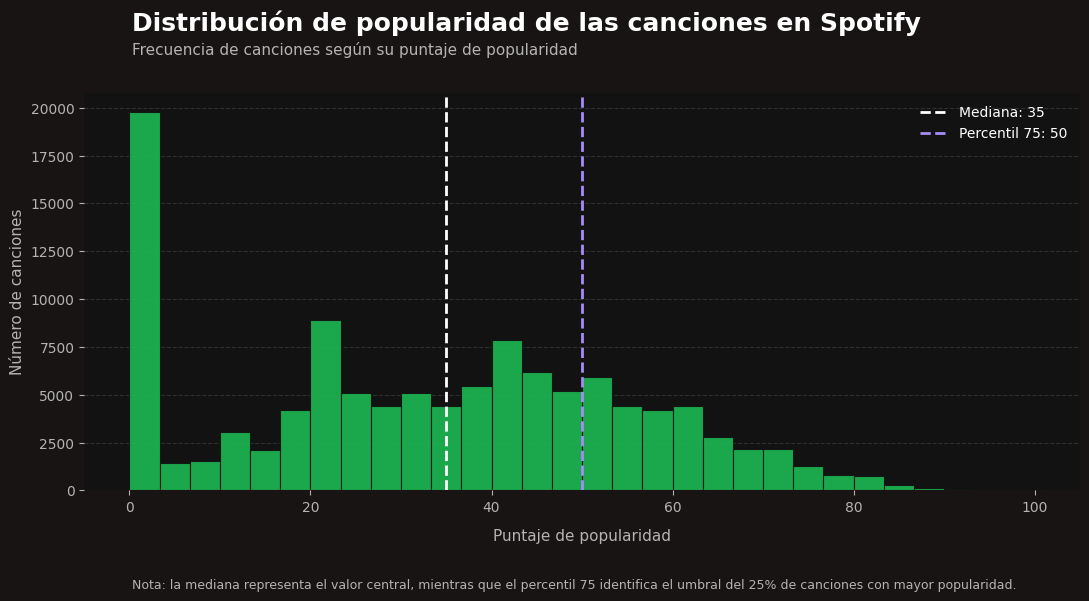

In [70]:
# Distribución de popularity
import matplotlib.pyplot as plt

# Métricas de referencia
median_popularity = df["popularity"].median()
p75_popularity = df["popularity"].quantile(0.75)

# Paleta Spotify
spotify_black = "#191414"
spotify_dark = "#121212"
spotify_green = "#1DB954"
spotify_gray = "#B3B3B3"
spotify_light = "#FFFFFF"
spotify_negative = "#6E6E73"
spotify_purple = "#A78BFA"

fig, ax = plt.subplots(figsize=(11, 6))

# Fondos
fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

# Histograma
ax.hist(
    df["popularity"].dropna(),
    bins=30,
    color=spotify_green,
    edgecolor=spotify_dark,
    linewidth=0.8,
    alpha=0.9
)

# Líneas de referencia
ax.axvline(
    median_popularity,
    color=spotify_light,
    linestyle="--",
    linewidth=2,
    label=f"Mediana: {median_popularity:.0f}"
)

ax.axvline(
    p75_popularity,
    color=spotify_purple,
    linestyle="--",
    linewidth=2,
    label=f"Percentil 75: {p75_popularity:.0f}"
)

# Título y subtítulo
fig.text(
    0.125,
    0.96,
    "Distribución de popularidad de las canciones en Spotify",
    color=spotify_light,
    fontsize=18,
    fontweight="bold"
)

fig.text(
    0.125,
    0.92,
    "Frecuencia de canciones según su puntaje de popularidad",
    color=spotify_gray,
    fontsize=11
)

# Ejes
ax.set_xlabel("Puntaje de popularidad", fontsize=11, color=spotify_gray, labelpad=10)
ax.set_ylabel("Número de canciones", fontsize=11, color=spotify_gray)

ax.tick_params(axis="x", colors=spotify_gray)
ax.tick_params(axis="y", colors=spotify_gray)

# Grid y bordes
ax.grid(axis="y", color="#3E3E3E", linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

# Leyenda
legend = ax.legend(
    frameon=False,
    loc="upper right",
    fontsize=10
)

for text in legend.get_texts():
    text.set_color(spotify_light)

# Nota
fig.text(
    0.125,
    0.03,
    "Nota: la mediana representa el valor central, mientras que el percentil 75 identifica el umbral del 25% de canciones con mayor popularidad.",
    color=spotify_gray,
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 0.88])

plt.savefig(
    "../reports/figures/popularity_distribution_spotify_style.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

In [35]:
df["popularity"].describe()

count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

In [36]:
df["popularity"].quantile([0.25, 0.50, 0.75, 0.80, 0.90])

0.25    17.0
0.50    35.0
0.75    50.0
0.80    54.0
0.90    63.0
Name: popularity, dtype: float64

In [39]:
# Definición temporal de canción popular usando el percentil 75

threshold = 50

df["popular"] = (df["popularity"] >= threshold).astype(int)

target_summary = pd.DataFrame({
    "cantidad": df["popular"].value_counts().sort_index(),
    "porcentaje": (df["popular"].value_counts(normalize=True).sort_index() * 100).round(2)
})

target_summary.index = ["No popular (0)", "Popular (1)"]

target_summary

,cantidad,porcentaje
No popular (0),84633,74.24
Popular (1),29367,25.76


### Hallazgo 7 — Definición y balance de la variable objetivo

La variable `popularity` presenta una mediana de 35 y un percentil 75 de 50. Por esta razón, se definió como canción popular aquella con una puntuación de popularidad mayor o igual a 50.

El umbral de 50 no fue elegido de forma arbitraria: corresponde al percentil 75 de la distribución observada y representa el segmento superior de popularidad dentro del dataset.

Con esta definición, el 25,76% de las canciones se clasifica como popular y el 74,24% como no popular. Existe un desbalance moderado de clases, por lo que más adelante se usarán particiones estratificadas y métricas enfocadas en la clase popular, especialmente Recall, Precision y F1-score.

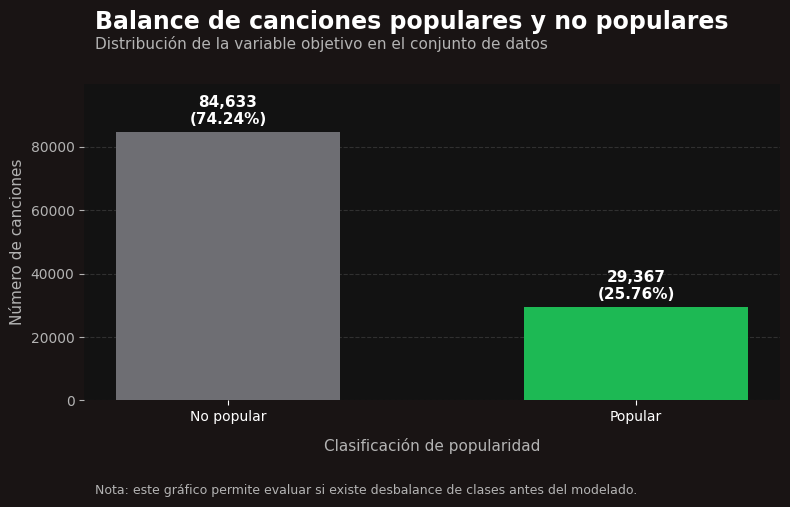

In [69]:
# Balance de la variable objetivo
import matplotlib.pyplot as plt

target_counts = df["popular"].value_counts().sort_index()

labels = ["No popular", "Popular"]
values = target_counts.values
percentages = (values / values.sum() * 100).round(2)

# Paleta Spotify
spotify_black = "#191414"
spotify_dark = "#121212"
spotify_green = "#1DB954"
spotify_gray = "#B3B3B3"
spotify_light = "#FFFFFF"
spotify_negative = "#6E6E73"

fig, ax = plt.subplots(figsize=(8, 5))

# Fondos
fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

# Barras
bars = ax.bar(
    labels,
    values,
    color=[spotify_negative, spotify_green],
    width=0.55
)

# Título y subtítulo
fig.text(
    0.125,
    0.96,
    "Balance de canciones populares y no populares",
    color=spotify_light,
    fontsize=17,
    fontweight="bold"
)

fig.text(
    0.125,
    0.92,
    "Distribución de la variable objetivo en el conjunto de datos",
    color=spotify_gray,
    fontsize=11
)

# Ejes
ax.set_xlabel("Clasificación de popularidad", fontsize=11, color=spotify_gray, labelpad=10)
ax.set_ylabel("Número de canciones", fontsize=11, color=spotify_gray)

ax.tick_params(axis="x", colors=spotify_light)
ax.tick_params(axis="y", colors=spotify_gray)

# Grid
ax.grid(axis="y", color="#3E3E3E", linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

# Quitar bordes
for spine in ax.spines.values():
    spine.set_visible(False)

# Etiquetas encima de las barras
offset = values.max() * 0.02

for bar, value, pct in zip(bars, values, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset,
        f"{value:,}\n({pct}%)",
        ha="center",
        va="bottom",
        color=spotify_light,
        fontsize=11,
        fontweight="bold"
    )

ax.set_ylim(0, values.max() * 1.18)

# Nota
fig.text(
    0.125,
    0.03,
    "Nota: este gráfico permite evaluar si existe desbalance de clases antes del modelado.",
    color=spotify_gray,
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 0.88])

plt.savefig(
    "../reports/figures/target_balance_spotify_style.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

In [41]:
audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

audio_by_popularity = (
    df.groupby("popular")[audio_features]
    .median()
    .T
)

audio_by_popularity.columns = ["No popular", "Popular"]

audio_by_popularity["Diferencia"] = (
    audio_by_popularity["Popular"] - audio_by_popularity["No popular"]
)

audio_by_popularity.sort_values("Diferencia", ascending=False)

,No popular,Popular,Diferencia
loudness,-7.119000,-6.691000,0.428000
danceability,0.576000,0.591000,0.015000
instrumentalness,0.000055,0.000023,-0.000032
speechiness,0.049700,0.046800,-0.002900
acousticness,0.172000,0.160000,-0.012000
liveness,0.136000,0.124000,-0.012000
energy,0.691000,0.668000,-0.023000
valence,0.476000,0.435000,-0.041000
tempo,122.344000,121.140000,-1.204000


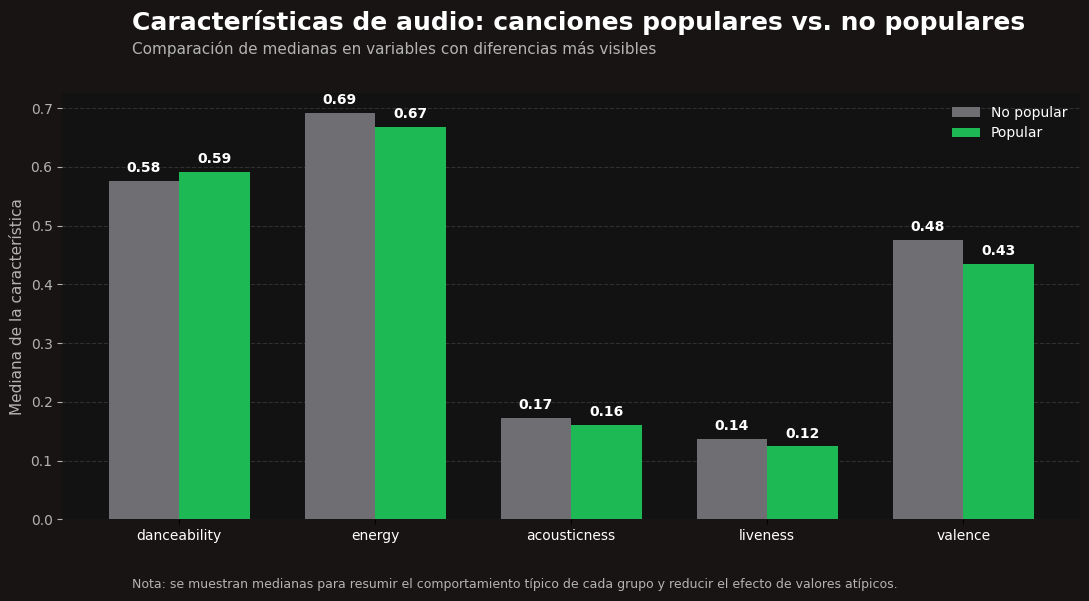

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Comparación enfocada de variables de audio con diferencias más visibles
features_focus = [
    "danceability",
    "energy",
    "acousticness",
    "liveness",
    "valence"
]

comparison_focus = (
    df.groupby("popular")[features_focus]
    .median()
    .T
)

comparison_focus.columns = ["No popular", "Popular"]

# Paleta Spotify
spotify_black = "#191414"
spotify_dark = "#121212"
spotify_green = "#1DB954"
spotify_gray = "#B3B3B3"
spotify_light = "#FFFFFF"
spotify_negative = "#6E6E73"

fig, ax = plt.subplots(figsize=(11, 6))

# Fondos
fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

# Barras
x = np.arange(len(comparison_focus.index))
width = 0.36

bars1 = ax.bar(
    x - width / 2,
    comparison_focus["No popular"],
    width=width,
    color=spotify_negative,
    label="No popular"
)

bars2 = ax.bar(
    x + width / 2,
    comparison_focus["Popular"],
    width=width,
    color=spotify_green,
    label="Popular"
)

# Etiquetas de valores
for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.01,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            color=spotify_light,
            fontsize=10,
            fontweight="bold"
        )

# Título y subtítulo
fig.text(
    0.125,
    0.96,
    "Características de audio: canciones populares vs. no populares",
    color=spotify_light,
    fontsize=18,
    fontweight="bold"
)

fig.text(
    0.125,
    0.92,
    "Comparación de medianas en variables con diferencias más visibles",
    color=spotify_gray,
    fontsize=11
)

# Ejes
ax.set_xlabel("")
ax.set_ylabel("Mediana de la característica", color=spotify_gray, fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(comparison_focus.index, rotation=0, color=spotify_light)

ax.tick_params(axis="y", colors=spotify_gray)
ax.grid(axis="y", color="#3E3E3E", linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

# Leyenda
legend = ax.legend(title="", frameon=False)
for text in legend.get_texts():
    text.set_color(spotify_light)

# Quitar bordes
for spine in ax.spines.values():
    spine.set_visible(False)

# Nota
fig.text(
    0.125,
    0.03,
    "Nota: se muestran medianas para resumir el comportamiento típico de cada grupo y reducir el efecto de valores atípicos.",
    color=spotify_gray,
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 0.88])

plt.savefig(
    "../reports/figures/audio_features_focus_by_popularity_spotify_style.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

### Hallazgo 8 — Características de audio y popularidad

Las canciones clasificadas como populares presentan una mediana de `danceability` ligeramente superior a las no populares. En cambio, las canciones no populares muestran medianas algo mayores en `energy`, `acousticness`, `liveness` y `valence`.

Las diferencias observadas son moderadas, por lo que ninguna característica individual explica por sí sola la popularidad. Esto justifica utilizar un modelo de machine learning que combine múltiples variables de audio y género musical para identificar patrones más complejos.

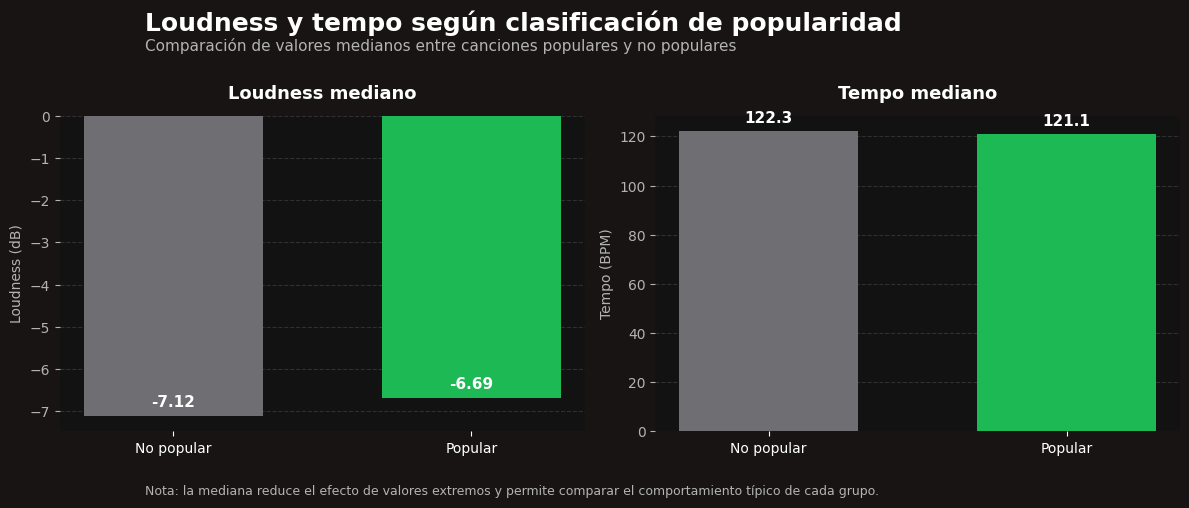

In [67]:
# Comparación de loudness y tempo según popularidad
import matplotlib.pyplot as plt

summary_rhythm = (
    df.groupby("popular")[["loudness", "tempo"]]
    .median()
    .T
)

summary_rhythm.columns = ["No popular", "Popular"]

# Paleta Spotify
spotify_black = "#191414"
spotify_dark = "#121212"
spotify_green = "#1DB954"
spotify_gray = "#B3B3B3"
spotify_light = "#FFFFFF"
spotify_negative = "#6E6E73"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fondo general
fig.patch.set_facecolor(spotify_black)

for ax in axes:
    ax.set_facecolor(spotify_dark)
    ax.grid(axis="y", color="#3E3E3E", linestyle="--", alpha=0.7)
    ax.set_axisbelow(True)

    ax.tick_params(axis="x", colors=spotify_light)
    ax.tick_params(axis="y", colors=spotify_gray)

    for spine in ax.spines.values():
        spine.set_visible(False)

categories = ["No popular", "Popular"]
bar_colors = [spotify_negative, spotify_green]

# Loudness
loudness_values = summary_rhythm.loc["loudness"]

bars_loudness = axes[0].bar(
    categories,
    loudness_values,
    color=bar_colors,
    width=0.6
)

axes[0].set_title(
    "Loudness mediano",
    color=spotify_light,
    fontsize=13,
    fontweight="bold",
    pad=12
)
axes[0].set_ylabel("Loudness (dB)", color=spotify_gray)

for bar, value in zip(bars_loudness, loudness_values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.15,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        color=spotify_light,
        fontsize=11,
        fontweight="bold"
    )

# Tempo
tempo_values = summary_rhythm.loc["tempo"]

bars_tempo = axes[1].bar(
    categories,
    tempo_values,
    color=bar_colors,
    width=0.6
)

axes[1].set_title(
    "Tempo mediano",
    color=spotify_light,
    fontsize=13,
    fontweight="bold",
    pad=12
)
axes[1].set_ylabel("Tempo (BPM)", color=spotify_gray)

for bar, value in zip(bars_tempo, tempo_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        color=spotify_light,
        fontsize=11,
        fontweight="bold"
    )

# Título y subtítulo
fig.text(
    0.125,
    0.96,
    "Loudness y tempo según clasificación de popularidad",
    color=spotify_light,
    fontsize=18,
    fontweight="bold"
)

fig.text(
    0.125,
    0.92,
    "Comparación de valores medianos entre canciones populares y no populares",
    color=spotify_gray,
    fontsize=11
)

# Nota inferior
fig.text(
    0.125,
    0.03,
    "Nota: la mediana reduce el efecto de valores extremos y permite comparar el comportamiento típico de cada grupo.",
    color=spotify_gray,
    fontsize=9
)

# Deja espacio para título y nota
plt.tight_layout(rect=[0, 0.08, 1, 0.88])

plt.savefig(
    "../reports/figures/loudness_tempo_by_popularity_spotify_style.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

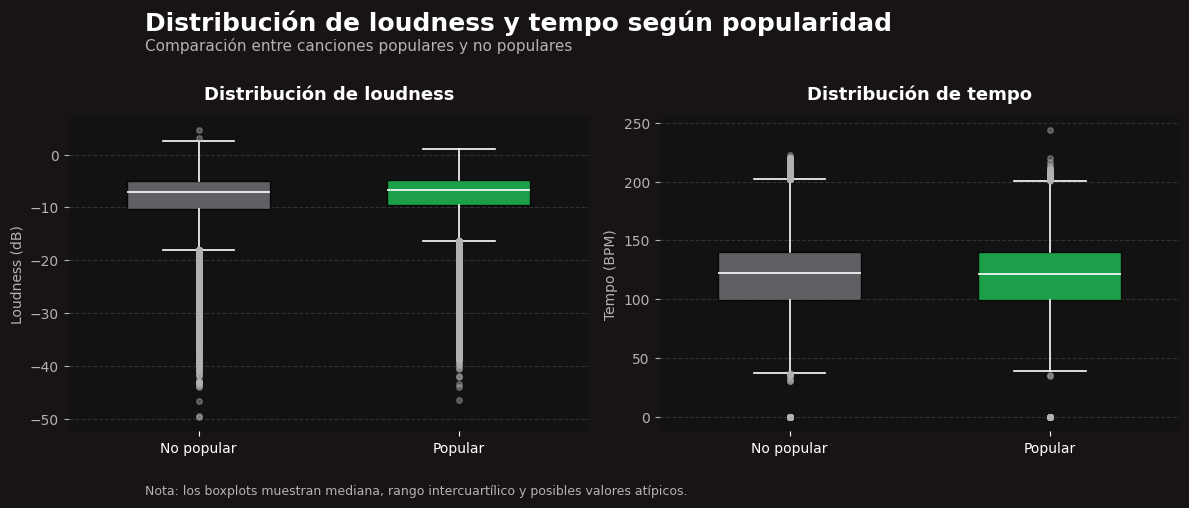

In [66]:
import matplotlib.pyplot as plt

# Ordenar grupos
loudness_data = [
    df[df["popular"] == 0]["loudness"].dropna(),
    df[df["popular"] == 1]["loudness"].dropna()
]

tempo_data = [
    df[df["popular"] == 0]["tempo"].dropna(),
    df[df["popular"] == 1]["tempo"].dropna()
]

# Paleta estilo Spotify
spotify_black = "#191414"
spotify_dark = "#121212"
spotify_green = "#1DB954"
spotify_gray = "#B3B3B3"
spotify_light = "#FFFFFF"
spotify_negative = "#6E6E73"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fondo general
fig.patch.set_facecolor(spotify_black)

for ax in axes:
    ax.set_facecolor(spotify_dark)
    ax.grid(axis="y", color="#3E3E3E", linestyle="--", alpha=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", colors=spotify_light)
    ax.tick_params(axis="y", colors=spotify_gray)
    
    for spine in ax.spines.values():
        spine.set_visible(False)

# Boxplot Loudness
bp1 = axes[0].boxplot(
    loudness_data,
    patch_artist=True,
    widths=0.55,
    labels=["No popular", "Popular"]
)

for patch, color in zip(bp1["boxes"], [spotify_negative, spotify_green]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for element in ["whiskers", "caps", "medians"]:
    for item in bp1[element]:
        item.set_color(spotify_light)
        item.set_linewidth(1.2)

for flier in bp1["fliers"]:
    flier.set(marker="o", markerfacecolor=spotify_gray, markeredgecolor=spotify_gray, alpha=0.4, markersize=4)

axes[0].set_title(
    "Distribución de loudness",
    color=spotify_light,
    fontsize=13,
    fontweight="bold",
    pad=12
)
axes[0].set_ylabel("Loudness (dB)", color=spotify_gray)

# Boxplot Tempo
bp2 = axes[1].boxplot(
    tempo_data,
    patch_artist=True,
    widths=0.55,
    labels=["No popular", "Popular"]
)

for patch, color in zip(bp2["boxes"], [spotify_negative, spotify_green]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

for element in ["whiskers", "caps", "medians"]:
    for item in bp2[element]:
        item.set_color(spotify_light)
        item.set_linewidth(1.2)

for flier in bp2["fliers"]:
    flier.set(marker="o", markerfacecolor=spotify_gray, markeredgecolor=spotify_gray, alpha=0.4, markersize=4)

axes[1].set_title(
    "Distribución de tempo",
    color=spotify_light,
    fontsize=13,
    fontweight="bold",
    pad=12
)
axes[1].set_ylabel("Tempo (BPM)", color=spotify_gray)

# Título principal
fig.text(
    0.125,
    0.96,
    "Distribución de loudness y tempo según popularidad",
    color=spotify_light,
    fontsize=18,
    fontweight="bold"
)

# Subtítulo
fig.text(
    0.125,
    0.92,
    "Comparación entre canciones populares y no populares",
    color=spotify_gray,
    fontsize=11
)

# Nota al pie
fig.text(
    0.125,
    0.03,
    "Nota: los boxplots muestran mediana, rango intercuartílico y posibles valores atípicos.",
    color=spotify_gray,
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 0.88])

plt.savefig(
    "../reports/figures/loudness_tempo_distribution_spotify_style.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

### Hallazgo 9 — Loudness y tempo

Las canciones populares presentan una mediana de `loudness` ligeramente menos negativa que las canciones no populares, lo que indica que, en promedio, tienden a tener un nivel sonoro algo mayor.

El `tempo` muestra distribuciones muy similares entre ambas clases, por lo que no parece diferenciar por sí solo la popularidad. Sin embargo, se mantendrá como predictor porque puede aportar información al combinarse con otras variables musicales.

Se observan valores extremos en `loudness` y `tempo`. Estos no se eliminarán automáticamente, ya que pueden representar canciones con estilos musicales, duraciones o características acústicas válidas. Los valores de `tempo = 0` ya fueron identificados como ausencia de medición rítmica.

In [46]:
# Popularidad promedio y proporción de canciones populares por género

genre_summary = (
    df.groupby("track_genre")
    .agg(
        canciones=("track_id", "size"),
        popularidad_promedio=("popularity", "mean"),
        proporcion_popular=("popular", "mean")
    )
)

genre_summary["proporcion_popular"] = (
    genre_summary["proporcion_popular"] * 100
).round(2)

genre_summary = genre_summary.sort_values(
    "popularidad_promedio",
    ascending=False
)

genre_summary.head(15)

,canciones,popularidad_promedio,proporcion_popular
track_genre,,,
pop-film,1000,59.283,94.4
k-pop,1000,56.896,71.2
chill,1000,53.651,78.3
sad,1000,52.379,69.6
grunge,1000,49.594,63.7
indian,1000,49.539,46.5
anime,1000,48.772,51.6
emo,1000,48.128,53.4
sertanejo,1000,47.866,27.5


### Hallazgo 10 — Diferencias de popularidad por género musical

La popularidad promedio y la proporción de canciones clasificadas como populares varían de forma importante entre géneros musicales.

Por ejemplo, `pop-film`, `k-pop`, `chill` y `sad` presentan proporciones elevadas de canciones populares, mientras que otros géneros como `brazil` muestran una proporción considerablemente menor.

### Implicación para el proyecto

El género musical puede aportar información predictiva relevante. Sin embargo, estas diferencias también pueden reflejar patrones históricos de promoción, exposición y representación dentro de Spotify, no únicamente calidad o potencial artístico.

Por esta razón, `track_genre` se considerará para el modelo, pero posteriormente se evaluará fairness para comprobar si el desempeño cambia de forma relevante entre grupos de géneros.

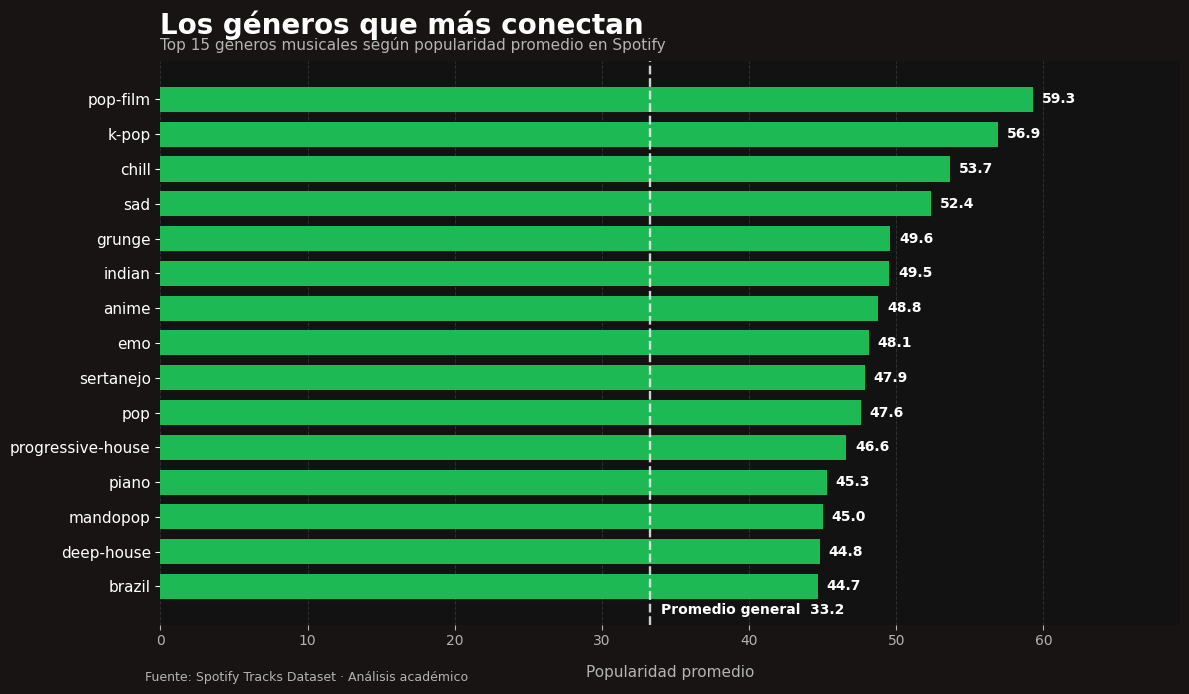

In [48]:
# Top 15 géneros musicales por popularidad promedio — Estilo Spotify

top_genres = (
    genre_summary
    .head(15)
    .sort_values("popularidad_promedio", ascending=True)
)

# Paleta inspirada en Spotify
spotify_black = "#191414"
spotify_dark = "#121212"
spotify_green = "#1DB954"
spotify_light = "#FFFFFF"
spotify_gray = "#B3B3B3"
spotify_grid = "#3E3E3E"

fig, ax = plt.subplots(figsize=(12, 7))

# Fondo general
fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

# Barras
bars = ax.barh(
    top_genres.index,
    top_genres["popularidad_promedio"],
    color=spotify_green,
    edgecolor="none",
    height=0.72
)

# Línea de promedio general
mean_popularity = df["popularity"].mean()

ax.axvline(
    mean_popularity,
    color=spotify_light,
    linestyle="--",
    linewidth=1.7,
    alpha=0.8
)

# Etiqueta de promedio
ax.text(
    mean_popularity + 0.8,
    -0.8,
    f"Promedio general  {mean_popularity:.1f}",
    color=spotify_light,
    fontsize=10,
    fontweight="bold"
)

# Valores al final de las barras
for bar, value in zip(bars, top_genres["popularidad_promedio"]):
    ax.text(
        value + 0.6,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        ha="left",
        color=spotify_light,
        fontsize=10,
        fontweight="bold"
    )

# Título y subtítulo
ax.set_title(
    "Los géneros que más conectan",
    loc="left",
    color=spotify_light,
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.text(
    0,
    1.02,
    "Top 15 géneros musicales según popularidad promedio en Spotify",
    transform=ax.transAxes,
    color=spotify_gray,
    fontsize=11
)

# Ejes y cuadrícula
ax.set_xlabel("Popularidad promedio", color=spotify_gray, fontsize=11, labelpad=12)
ax.set_ylabel("")

ax.tick_params(axis="x", colors=spotify_gray, labelsize=10)
ax.tick_params(axis="y", colors=spotify_light, labelsize=11)

ax.grid(axis="x", color=spotify_grid, linestyle="--", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)

# Quitar bordes
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(0, top_genres["popularidad_promedio"].max() + 10)

# Pie de gráfico
fig.text(
    0.125,
    0.02,
    "Fuente: Spotify Tracks Dataset · Análisis académico",
    color=spotify_gray,
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/top_genres_popularity_spotify_style.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

In [49]:
# Correlación entre características de audio y popularidad

correlation_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]

corr_matrix = df[correlation_features].corr()

# Correlación de cada variable respecto a popularidad
popularity_corr = (
    corr_matrix["popularity"]
    .drop("popularity")
    .sort_values(ascending=False)
)

popularity_corr

loudness            0.050423
danceability        0.035448
tempo               0.013205
energy              0.001056
liveness           -0.005387
duration_ms        -0.007101
acousticness       -0.025472
valence            -0.040534
speechiness        -0.044927
instrumentalness   -0.095139
Name: popularity, dtype: float64

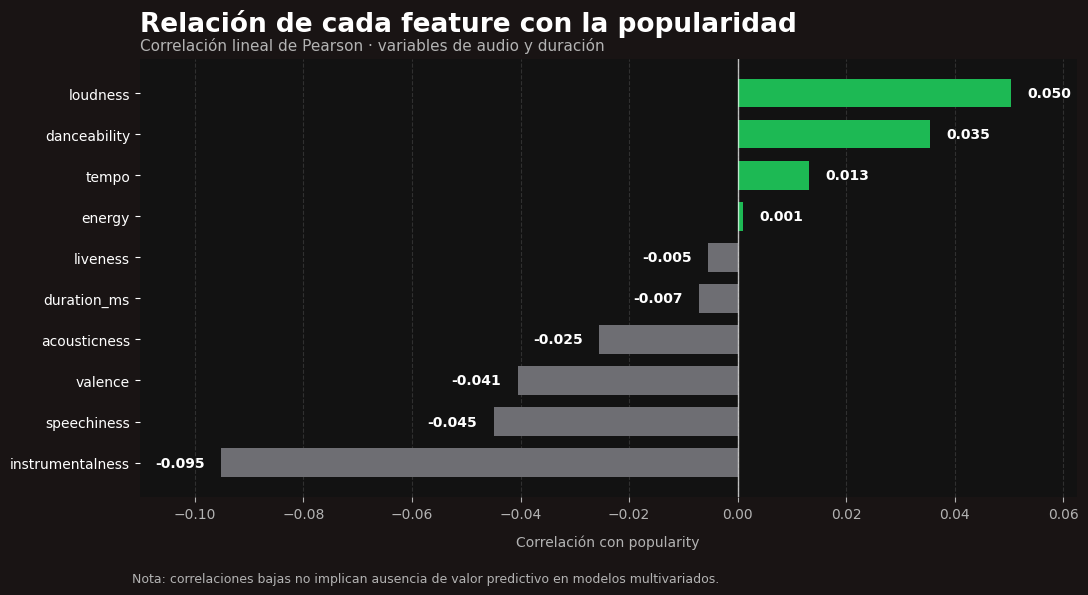

In [57]:
# Variables de audio con mayor relación lineal con popularidad

corr_plot = popularity_corr.sort_values()

spotify_black = "#191414"
spotify_dark = "#121212"
spotify_green = "#1DB954"
spotify_gray = "#B3B3B3"
spotify_light = "#FFFFFF"
spotify_negative = "#6E6E73"

fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_facecolor(spotify_black)
ax.set_facecolor(spotify_dark)

colors = [
    spotify_green if value > 0 else spotify_negative
    for value in corr_plot.values
]

bars = ax.barh(
    corr_plot.index,
    corr_plot.values,
    color=colors,
    height=0.7
)

ax.axvline(0, color=spotify_light, linewidth=1, alpha=0.7)

for bar, value in zip(bars, corr_plot.values):
    if value >= 0:
        position = value + 0.003
        alignment = "left"
    else:
        position = value - 0.003
        alignment = "right"

    ax.text(
        position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        ha=alignment,
        color=spotify_light,
        fontsize=10,
        fontweight="bold",
        clip_on=False
    )

ax.set_xlim(corr_plot.min() - 0.015, corr_plot.max() + 0.012)

ax.set_title(
    "Relación de cada feature con la popularidad",
    loc="left",
    color=spotify_light,
    fontsize=19,
    fontweight="bold",
    pad=20
)

ax.text(
    0,
    1.02,
    "Correlación lineal de Pearson · variables de audio y duración",
    transform=ax.transAxes,
    color=spotify_gray,
    fontsize=11
)

ax.set_xlabel("Correlación con popularity", color=spotify_gray, labelpad=10)
ax.set_ylabel("")

ax.tick_params(axis="x", colors=spotify_gray)
ax.tick_params(axis="y", colors=spotify_light)

ax.grid(axis="x", color="#3E3E3E", linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(
    0.125,
    0.02,
    "Nota: correlaciones bajas no implican ausencia de valor predictivo en modelos multivariados.",
    color=spotify_gray,
    fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig(
    "../reports/figures/popularity_correlations_spotify_style.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

### Hallazgo 11 — Correlación con popularidad

Las correlaciones lineales entre las variables individuales y `popularity` son bajas. La relación positiva más alta corresponde a `loudness` (0,050), seguida por `danceability` (0,035).

La relación negativa más marcada corresponde a `instrumentalness` (-0,095), aunque sigue siendo una asociación débil.

### Decisión preliminar

No se eliminarán variables únicamente por presentar correlaciones lineales bajas. La popularidad musical puede depender de combinaciones no lineales entre características de audio, género y contexto de la canción. Por ello, se evaluarán modelos multivariados capaces de capturar interacciones más complejas.

In [62]:
# Análisis de duración
df["duration_ms"].describe()

count    1.140000e+05
mean     2.280292e+05
std      1.072977e+05
min      0.000000e+00
25%      1.740660e+05
50%      2.129060e+05
75%      2.615060e+05
max      5.237295e+06
Name: duration_ms, dtype: float64

In [59]:
(df["duration_ms"] / 60000).describe()

count    114000.000000
mean          3.800486
std           1.788295
min           0.000000
25%           2.901100
50%           3.548433
75%           4.358433
max          87.288250
Name: duration_ms, dtype: float64

In [60]:
long_songs = df[df["duration_ms"] > df["duration_ms"].quantile(0.99)]

print("Canciones por encima del percentil 99:", len(long_songs))

long_songs[
    ["track_id", "artists", "track_name", "duration_ms", "popularity", "track_genre"]
].head(15)

Canciones por encima del percentil 99: 1140


,track_id,artists,track_name,duration_ms,popularity,track_genre
851,5fomS2mZjvxxJ2iVH3fosc,John Elliott,All Too Well - Jake's Version,578064,33,acoustic
1251,4TbIOAb7FfbhHi2glq0EwA,Cymande,Dove,655440,48,afrobeat
1267,2oWex6rYoQ7Bl2D9zG8d3F,Fela Kuti,Water No Get Enemy,591693,48,afrobeat
1505,3RZoPvPHZsPTTc94DfWSCL,Fela Kuti,Zombie,745653,41,afrobeat
1541,74ZYdKyVYgiemIALe3w5Za,William Onyeabor,The Moon and The Sun,560280,20,afrobeat
1585,2kXcbzDysxMAoOcM4Gtrkq,Newen Afrobeat,Nación Nueva,579760,18,afrobeat
1644,16zRyplwDUve1JKipYBdEt,Newen Afrobeat,Qué Sabemos,625066,18,afrobeat
1688,7qGrjVQQmh6blinO4DyK3c,Fela Kuti,Lady,828586,18,afrobeat
1794,6v3BRYhBazEhyhm6FeKXL2,Newen Afrobeat,Come y Calla,540346,17,afrobeat
1820,3IQvH607gDiHXdT8wnqgtC,Tony Allen With Africa 70,Jealousy,683893,17,afrobeat


In [61]:
longest_songs = df.nlargest(
    10,
    "duration_ms"
)[
    [
        "track_id",
        "artists",
        "track_name",
        "duration_ms",
        "popularity",
        "track_genre"
    ]
].copy()

longest_songs["duration_minutes"] = (
    longest_songs["duration_ms"] / 60000
).round(2)

longest_songs

,track_id,artists,track_name,duration_ms,popularity,track_genre,duration_minutes
73617,3Cnz3Bu9Wcw8p3kiBTXTxp,Tale Of Us,Unity (Voyage Mix) Pt. 1,5237295,35,minimal-techno,87.29
10935,0LBIf9EFHuxmuNig4JHGZo,Timo Maas,Crossing Wires 002 - Continuous DJ Mix,4789026,11,breakbeat,79.82
10984,0LBIf9EFHuxmuNig4JHGZo,Timo Maas,Crossing Wires 002 - Continuous DJ Mix,4789026,11,breakbeat,79.82
24348,6wypxnAvmv5zYewUX3VFDd,Seth Troxler,The Lab 03 - Continuous DJ Mix Part 1,4730302,8,detroit-techno,78.84
73840,6JbQr97EMFD2D3Ek6gxgt1,Loco Dice,Amnesia Ibiza Underground 10 DJ Mix,4563897,17,minimal-techno,76.06
13344,3gFme8BdfTtFHxKmuTnSbj,Mark Farina,House of Om - Mark Farina - Continuous Mix,4447520,11,chicago-house,74.13
13245,13hQAhg1owjTpTcI9xQc6c,Mark Farina,Live In Tokyo - Continuous Mix,4339826,11,chicago-house,72.33
13195,3se0UYprtkHthJEBuk1A5K,Mark Farina,Greenhouse Construction,4334721,12,chicago-house,72.25
27926,6eTDnsdPlRUyrTHqFj3l7W,Lenzman;Dan Stezo,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",4246206,15,drum-and-bass,70.77
101390,2QfFLpSGF1T1pY6tq4kD7Z,Ocean Sounds,Ocean Waves Sounds,4120258,39,sleep,68.67


In [63]:
duration_summary = pd.DataFrame({
    "grupo_duracion": [
        "Menos de 1 minuto",
        "1 a 5 minutos",
        "5 a 10 minutos",
        "10 a 20 minutos",
        "Más de 20 minutos"
    ],
    "cantidad": [
        (df["duration_ms"] < 60_000).sum(),
        ((df["duration_ms"] >= 60_000) & (df["duration_ms"] < 300_000)).sum(),
        ((df["duration_ms"] >= 300_000) & (df["duration_ms"] < 600_000)).sum(),
        ((df["duration_ms"] >= 600_000) & (df["duration_ms"] < 1_200_000)).sum(),
        (df["duration_ms"] >= 1_200_000).sum()
    ]
})

duration_summary["porcentaje"] = (
    duration_summary["cantidad"] / len(df) * 100
).round(2)

duration_summary

,grupo_duracion,cantidad,porcentaje
0,Menos de 1 minuto,851,0.75
1,1 a 5 minutos,96774,84.89
2,5 a 10 minutos,15772,13.84
3,10 a 20 minutos,522,0.46
4,Más de 20 minutos,81,0.07


### Hallazgo 12 — Duración de las pistas

La duración típica de las pistas se concentra entre 1 y 5 minutos, grupo que representa el 84,89% del dataset. Las pistas de más de 20 minutos representan solo el 0,07% y corresponden principalmente a mezclas continuas de DJ, música electrónica de larga duración o contenido ambiental.

### Decisión preliminar

No se eliminarán automáticamente las canciones por duración extrema, ya que los registros revisados corresponden a contenido musical válido. La variable `duration_ms` se conservará como predictor y, durante la preparación para modelado, se evaluará transformar su escala o crear una variable indicadora de contenido de larga duración.

In [64]:
# Popularidad según grupo de duración

duration_popularity = df.assign(
    grupo_duracion=pd.cut(
        df["duration_ms"] / 60000,
        bins=[-1, 1, 5, 10, 20, float("inf")],
        labels=[
            "Menos de 1 minuto",
            "1 a 5 minutos",
            "5 a 10 minutos",
            "10 a 20 minutos",
            "Más de 20 minutos"
        ]
    )
).groupby(
    "grupo_duracion",
    observed=False
).agg(
    canciones=("track_id", "size"),
    popularidad_promedio=("popularity", "mean"),
    mediana_popularidad=("popularity", "median"),
    proporcion_popular=("popular", "mean")
)

duration_popularity["proporcion_popular"] = (
    duration_popularity["proporcion_popular"] * 100
).round(2)

duration_popularity.round(2)

,canciones,popularidad_promedio,mediana_popularidad,proporcion_popular
grupo_duracion,,,,
Menos de 1 minuto,873,21.94,21.0,5.50
1 a 5 minutos,96779,33.70,35.0,27.01
5 a 10 minutos,15745,31.35,31.0,19.90
10 a 20 minutos,522,24.43,22.0,8.81
Más de 20 minutos,81,25.59,27.0,3.70


### Hallazgo 13 — Popularidad según duración

Las pistas con duración entre 1 y 5 minutos presentan la mayor popularidad promedio y la mayor proporción de canciones populares dentro del dataset.

En contraste, las pistas muy cortas y las pistas de más de 10 minutos muestran una proporción menor de canciones populares. Esto puede estar relacionado con que las mezclas continuas, piezas ambientales o contenido de larga duración no siguen el formato comercial habitual de una canción individual.

### Decisión preliminar

La duración se conservará como predictor numérico. Además, se evaluará la creación de una variable `is_long_track`, que identificará pistas de 10 minutos o más, para capturar posibles diferencias entre canciones convencionales y contenido de larga duración sin eliminar registros válidos.

In [71]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Spotify Tracks Dataset — Reporte de Calidad",
    explorative=True,
    minimal=False
)

profile.to_file("../reports/eda_report.html")


C:\Users\GABY\AppData\Local\Temp\ipykernel_636\2973827972.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 23/23 [00:03<00:00,  6.92it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Reporte automático de calidad de datos

Se generó un reporte exploratorio automatizado mediante la librería `ydata-profiling`.

El archivo se guardó en:

`reports/eda_report.html`

Este reporte complementa el análisis manual realizado en el notebook e incluye revisiones de tipos de datos, valores faltantes, duplicados, distribuciones, correlaciones y posibles alertas de calidad.